### Invariant of neural representation

- build multivariate gaussian distribution with covariance matrix
- The covariance matrix is built by rotating the original covariance matrix
- The rotation is done by a design matrix B.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
from sklearn.decomposition import PCA
from hebbian.utils import instantiate_rotated_data, generate_covariance_matrix

In [2]:
N = 64
m = 4
phi_deg = 45.0
n_samples = 10001
X_seed = 0
# get /sigma
# eigenvalues = np.array([2.0, 0.8])  # Your desired eigenvalues

eigenvalues = np.array([3.0, 1.8, 1.0, 0.3])  # Your desired eigenvalues
Sigma = generate_covariance_matrix(dim=m, eigenvalues=eigenvalues, method="eigenvalues")

# B. Generate Data (Rotate 45 degrees)
X_before, X_after = instantiate_rotated_data(N, m, Sigma, phi_rad=np.deg2rad(phi_deg), seed=X_seed, n_samples=n_samples)


# Do PCA on X before and X after
pca_before = PCA(n_components=m)
pca_before.fit(X_before)
X_before_pca = pca_before.transform(X_before)
pca_after = PCA(n_components=m)
pca_after.fit(X_after)
X_after_pca = pca_after.transform(X_after)

# eigen values of X before and X after
print(f"Eigen values of X before: {pca_before.explained_variance_}")
print(f"Eigen values of X after: {pca_after.explained_variance_}")

# variance explained by each PC
print(f"Variance explained by each PC of X before: {pca_before.explained_variance_ratio_}")
print(f"Variance explained by each PC of X after: {pca_after.explained_variance_ratio_}")



Eigen values of X before: [3.01336044 1.78684492 1.00748662 0.30282245]
Eigen values of X after: [3.01336044 1.78684492 1.00748662 0.30282245]
Variance explained by each PC of X before: [0.4931435  0.29242136 0.16487754 0.0495576 ]
Variance explained by each PC of X after: [0.4931435  0.29242136 0.16487754 0.0495576 ]


### Apply Leen's complete model to before and after drifted models

In [18]:
from hebbian.models import OneShotLeenCompletePCA, OneShotLeenReislebenPCA
from hebbian.utils import Y_aligned_training_testing, Y_aligned_training_testing_online

### Multiple runs

In [15]:
### Two phase training and testing

def bar_graph_with_error_bars(df_best_corr, title):
    figure = plt.figure()
    means = df_best_corr.mean(axis=0)
    stds = df_best_corr.std(axis=0)
    plt.figure(figsize=(10, 6))
    plt.bar(means.index, means.values, yerr=stds.values, capsize=5)
    plt.ylabel('Mean Absolute Correlation')
    plt.title(title)
    plt.show()

def two_phase_training_testing(model, data_before, data_after, m, model_paras_after=None, runs =10, graph = True):
    df_best_corr_after = pd.DataFrame(data=np.full((runs, m), np.nan), 
                            columns=[f"PC_{i+1}" for i in range(m)],
                            index=[f"run_{i+1}" for i in range(runs)])
    df_best_corr_before = pd.DataFrame(data=np.full((runs, m), np.nan), 
                            columns=[f"PC_{i+1}" for i in range(m)],
                            index=[f"run_{i+1}" for i in range(runs)])

    for run in range(runs):
        print(f"run {run+1:2d}")
        print(f"X_before")
        order, similarity = Y_aligned_training_testing_online(model, data_before, graph=True, alignment="cov")
        # print(f"After first phase: model.W = {model.W}, model.V: {model.V}")

        # print(f"Y_output_after_first_phase: {model.transform(data_before)}")
       # based on the order, sort the similarity to match PC order
        combined_lists = zip(order, similarity)
        # Sort the pairs based on PC_orders
        sorted_combined_lists = sorted(combined_lists)
        # Unzip the sorted pairs
        _, ordered_similarity = zip(*sorted_combined_lists)
        df_best_corr_before.iloc[run, :] = ordered_similarity 

#################################################################
        print(f"X_after")
        # update the model parameters, if provided
        if model_paras_after is not None:
            for key, value in model_paras_after.items():
                if hasattr(model, key):
                    setattr(model, key, value)

        order, similarity = Y_aligned_training_testing_online(model, data_after, graph=True, alignment="cosine")

        # based on the order, sort the similarity to match PC order
        combined_lists = zip(order, similarity)
        # Sort the pairs based on PC_orders
        sorted_combined_lists = sorted(combined_lists)
        # Unzip the sorted pairs
        _, ordered_similarity = zip(*sorted_combined_lists)
        df_best_corr_after.iloc[run, :] = ordered_similarity
        # print(f"run {run+1:2d} | order = {order} | best|corr|= {np.round(similarity,3)}")
        model.reset()

    if graph == True:
        bar_graph_with_error_bars(df_best_corr_before, "Mean Absolute Correlation (before)")
        bar_graph_with_error_bars(df_best_corr_after, "Mean Absolute Correlation (after)")

### Golden standard: Sanger's rule

In [ ]:
from hebbian.models import SangerNetwork
sanger_model = SangerNetwork(output_size=m, learning_rate=0.011, rng=None)

sanger_model_after = dict(learning_rate=0.01)

two_phase_training_testing(sanger_model, X_before, X_after, m, model_paras_after = sanger_model_after, runs = 10, graph = True)

### Leen's complete model

In [20]:
# runs = 10
model_paras = dict(
    input_dim=N, output_dim=m,
    eta_w=5e-4,          # base
    eta_v=1e-3,          # ~4x eta_w
    C=3,
    # ema_alpha=0.05,
    symmetrize_V=True,
    seed=None,
    noise_level=0.001,
    # settling_steps=10
)

model_paras_after = dict(
    eta_w=5e-4,
    eta_v=5e-3,
#     eta_w=6e-5,          # base
#     eta_v=5e-4,          # ~4x eta_w
)

run  1
X_before
step    0 | order = [2 1 3 0] | best|corr|= [0.216 0.034 0.153 0.254]
step 1000 | order = [2 3 1 0] | best|corr|= [0.297 0.136 0.132 0.698]
step 2000 | order = [2 3 1 0] | best|corr|= [0.437 0.174 0.308 0.973]
step 3000 | order = [2 3 1 0] | best|corr|= [0.585 0.226 0.575 0.998]
step 4000 | order = [2 3 1 0] | best|corr|= [0.746 0.276 0.796 0.999]
step 5000 | order = [2 3 1 0] | best|corr|= [0.868 0.316 0.921 1.   ]
step 6000 | order = [2 3 1 0] | best|corr|= [0.932 0.366 0.962 1.   ]
step 7000 | order = [2 3 1 0] | best|corr|= [0.966 0.417 0.972 1.   ]
step 8000 | order = [2 3 1 0] | best|corr|= [0.982 0.469 0.982 1.   ]
step 9000 | order = [2 3 1 0] | best|corr|= [0.988 0.526 0.989 1.   ]
step 10000 | order = [2 3 1 0] | best|corr|= [0.993 0.586 0.987 1.   ]


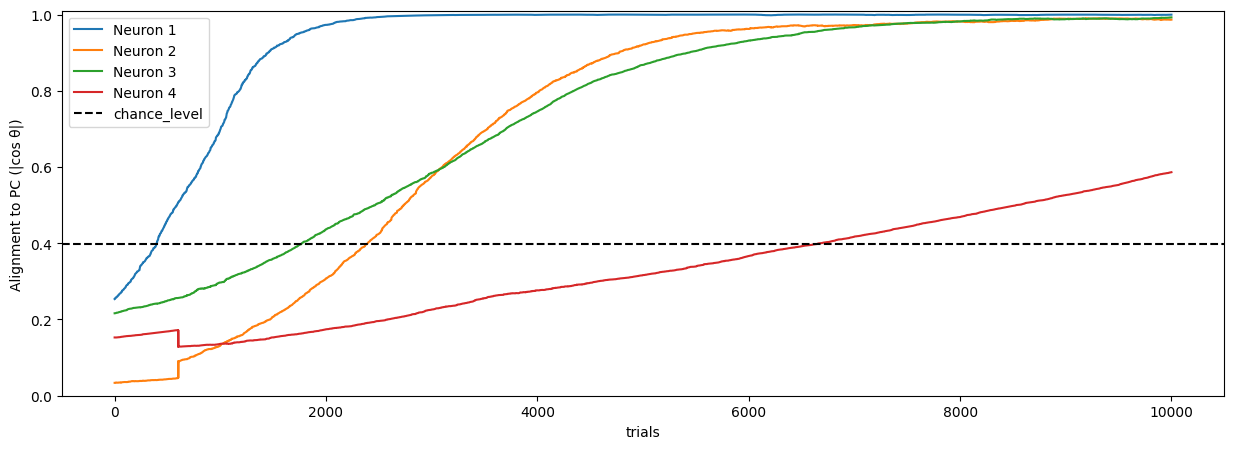

X_after
step    0 | order = [2 3 1 0] | best|corr|= [0.853 0.505 0.836 0.814]
step 1000 | order = [2 3 1 0] | best|corr|= [0.926 0.607 0.813 0.897]
step 2000 | order = [2 3 1 0] | best|corr|= [0.94  0.669 0.858 0.935]
step 3000 | order = [2 3 1 0] | best|corr|= [0.953 0.72  0.894 0.958]
step 4000 | order = [2 3 1 0] | best|corr|= [0.965 0.766 0.914 0.974]
step 5000 | order = [2 3 1 0] | best|corr|= [0.98  0.809 0.935 0.981]
step 6000 | order = [2 3 1 0] | best|corr|= [0.985 0.847 0.953 0.986]
step 7000 | order = [2 3 1 0] | best|corr|= [0.988 0.88  0.964 0.991]
step 8000 | order = [2 3 1 0] | best|corr|= [0.989 0.906 0.976 0.997]
step 9000 | order = [2 3 1 0] | best|corr|= [0.99  0.929 0.984 0.996]
step 10000 | order = [2 3 1 0] | best|corr|= [0.993 0.946 0.985 0.998]


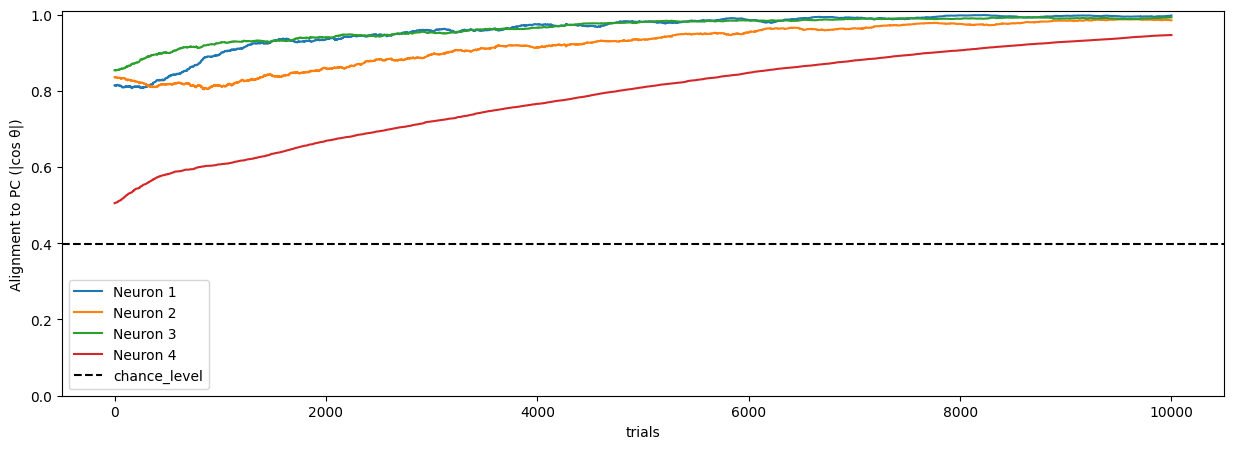

run  2
X_before
step    0 | order = [1 0 2 3] | best|corr|= [0.099 0.091 0.212 0.177]
step 1000 | order = [1 3 2 0] | best|corr|= [0.195 0.08  0.327 0.413]
step 2000 | order = [3 1 2 0] | best|corr|= [0.008 0.553 0.466 0.672]
step 3000 | order = [3 1 2 0] | best|corr|= [0.007 0.737 0.635 0.8  ]
step 4000 | order = [3 1 2 0] | best|corr|= [0.014 0.863 0.8   0.798]
step 5000 | order = [3 1 2 0] | best|corr|= [0.017 0.897 0.901 0.85 ]
step 6000 | order = [3 1 2 0] | best|corr|= [0.015 0.935 0.954 0.869]
step 7000 | order = [3 1 2 0] | best|corr|= [0.016 0.955 0.978 0.905]
step 8000 | order = [3 1 2 0] | best|corr|= [0.02  0.968 0.989 0.932]
step 9000 | order = [3 1 2 0] | best|corr|= [0.024 0.966 0.996 0.966]
step 10000 | order = [3 1 2 0] | best|corr|= [0.028 0.978 0.997 0.974]


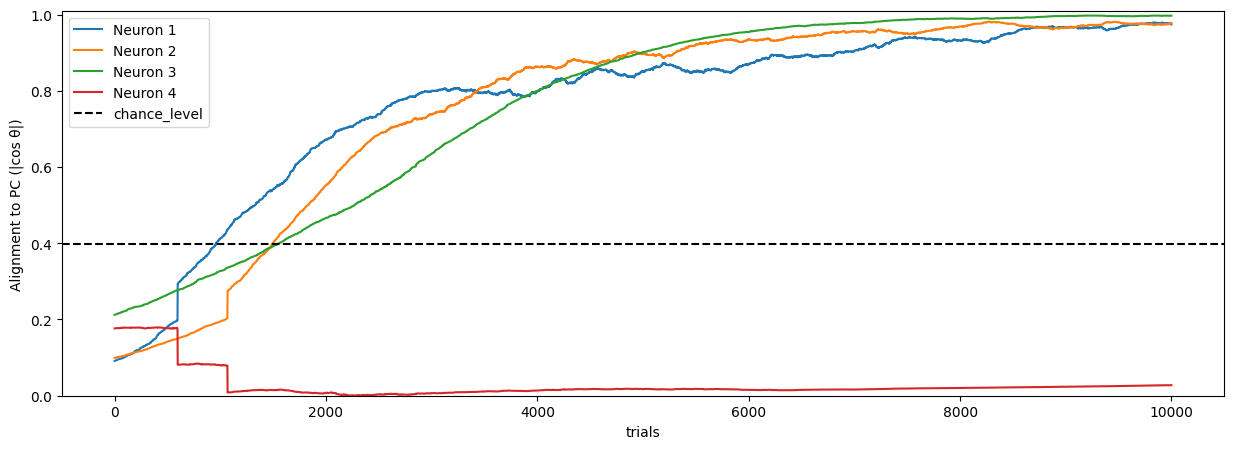

X_after
step    0 | order = [3 1 2 0] | best|corr|= [0.024 0.951 0.89  0.875]
step 1000 | order = [3 1 2 0] | best|corr|= [0.03  0.946 0.97  0.951]
step 2000 | order = [3 1 2 0] | best|corr|= [0.035 0.962 0.982 0.971]
step 3000 | order = [3 1 2 0] | best|corr|= [0.041 0.978 0.985 0.981]
step 4000 | order = [3 1 2 0] | best|corr|= [0.047 0.978 0.989 0.99 ]
step 5000 | order = [3 1 2 0] | best|corr|= [0.054 0.984 0.995 0.993]
step 6000 | order = [3 1 2 0] | best|corr|= [0.062 0.988 0.998 0.994]
step 7000 | order = [3 1 2 0] | best|corr|= [0.072 0.991 0.998 0.996]
step 8000 | order = [3 1 2 0] | best|corr|= [0.083 0.995 0.997 0.999]
step 9000 | order = [3 1 2 0] | best|corr|= [0.097 0.998 0.997 0.998]
step 10000 | order = [3 1 2 0] | best|corr|= [0.114 0.997 0.998 0.999]


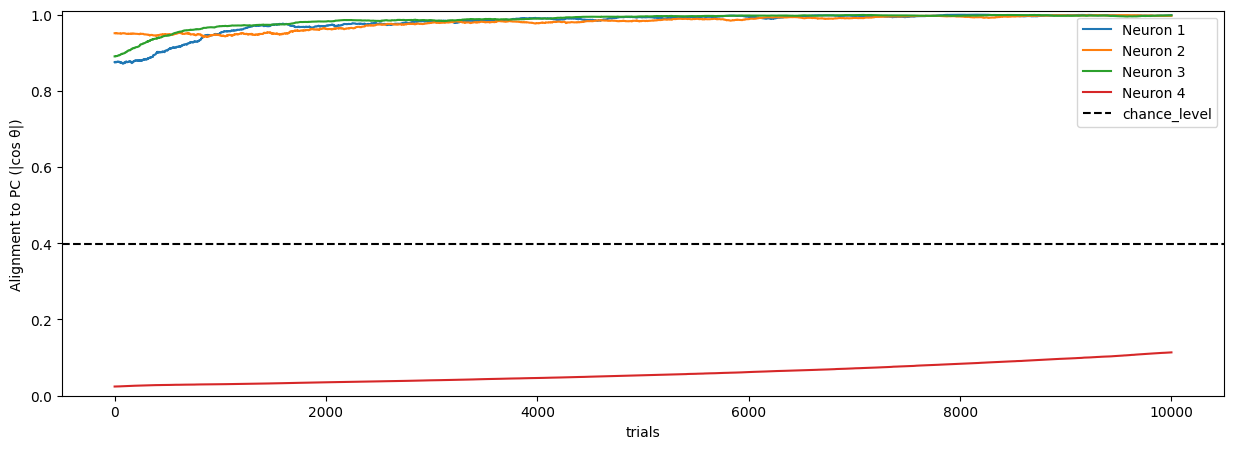

run  3
X_before
step    0 | order = [0 3 2 1] | best|corr|= [0.337 0.18  0.095 0.082]
step 1000 | order = [0 2 3 1] | best|corr|= [0.733 0.198 0.142 0.226]
step 2000 | order = [0 3 2 1] | best|corr|= [0.951 0.227 0.245 0.399]
step 3000 | order = [0 3 2 1] | best|corr|= [0.982 0.275 0.389 0.624]
step 4000 | order = [0 3 2 1] | best|corr|= [0.991 0.329 0.53  0.876]
step 5000 | order = [0 3 2 1] | best|corr|= [0.995 0.391 0.63  0.969]
step 6000 | order = [0 3 2 1] | best|corr|= [0.996 0.479 0.709 0.99 ]
step 7000 | order = [0 3 2 1] | best|corr|= [0.998 0.576 0.792 0.994]
step 8000 | order = [0 3 2 1] | best|corr|= [1.    0.668 0.863 0.996]
step 9000 | order = [0 3 2 1] | best|corr|= [0.998 0.742 0.917 0.997]
step 10000 | order = [0 3 2 1] | best|corr|= [0.999 0.796 0.954 0.999]


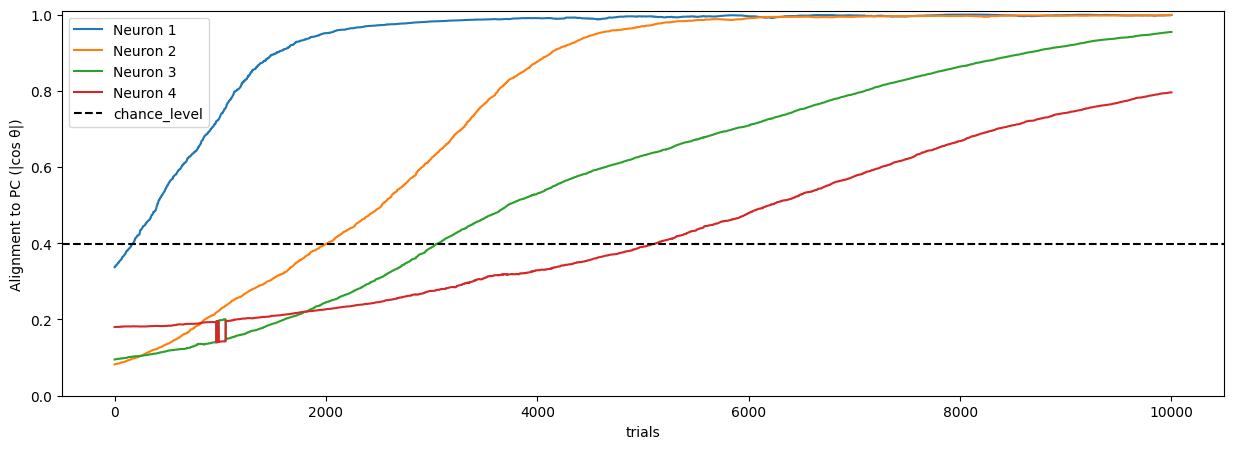

X_after
step    0 | order = [0 3 2 1] | best|corr|= [0.799 0.649 0.748 0.889]
step 1000 | order = [0 3 2 1] | best|corr|= [0.866 0.767 0.871 0.878]
step 2000 | order = [0 3 2 1] | best|corr|= [0.913 0.835 0.901 0.925]
step 3000 | order = [0 3 2 1] | best|corr|= [0.94  0.876 0.929 0.947]
step 4000 | order = [0 3 2 1] | best|corr|= [0.957 0.903 0.952 0.958]
step 5000 | order = [0 3 2 1] | best|corr|= [0.97  0.927 0.971 0.968]
step 6000 | order = [0 3 2 1] | best|corr|= [0.977 0.946 0.981 0.979]
step 7000 | order = [0 3 2 1] | best|corr|= [0.985 0.96  0.989 0.986]
step 8000 | order = [0 3 2 1] | best|corr|= [0.995 0.968 0.991 0.991]
step 9000 | order = [0 3 2 1] | best|corr|= [0.994 0.977 0.993 0.996]
step 10000 | order = [0 3 2 1] | best|corr|= [0.996 0.983 0.995 0.996]


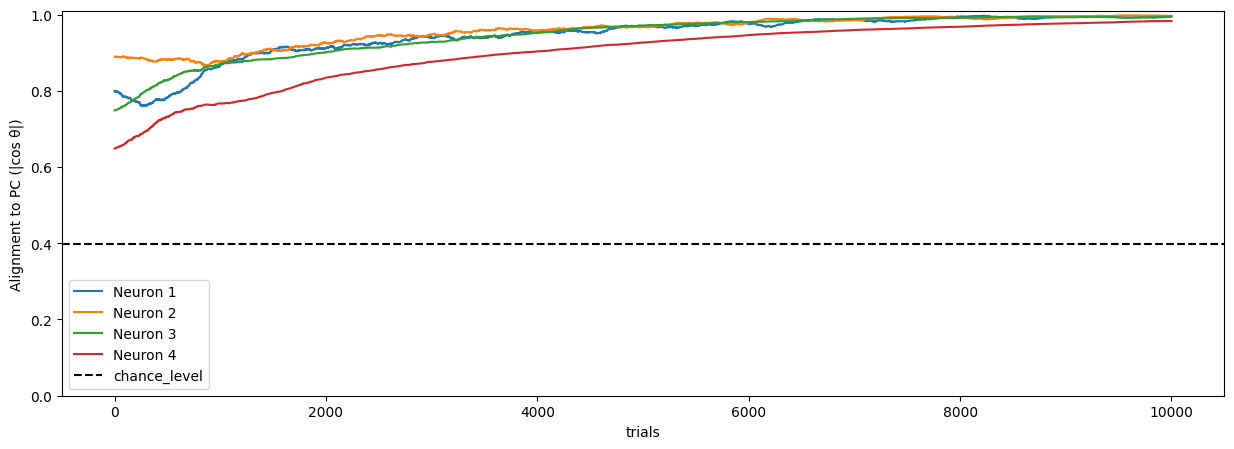

run  4
X_before
step    0 | order = [2 0 3 1] | best|corr|= [0.227 0.217 0.168 0.178]
step 1000 | order = [2 0 3 1] | best|corr|= [0.324 0.628 0.208 0.308]
step 2000 | order = [2 0 3 1] | best|corr|= [0.511 0.957 0.243 0.531]
step 3000 | order = [2 0 3 1] | best|corr|= [0.726 0.993 0.281 0.75 ]
step 4000 | order = [2 0 3 1] | best|corr|= [0.858 0.993 0.322 0.897]
step 5000 | order = [2 0 3 1] | best|corr|= [0.927 0.996 0.368 0.953]
step 6000 | order = [2 0 3 1] | best|corr|= [0.961 0.998 0.417 0.974]
step 7000 | order = [2 0 3 1] | best|corr|= [0.976 0.998 0.468 0.981]
step 8000 | order = [2 0 3 1] | best|corr|= [0.986 0.998 0.524 0.983]
step 9000 | order = [2 0 3 1] | best|corr|= [0.993 1.    0.584 0.981]
step 10000 | order = [2 0 3 1] | best|corr|= [0.995 0.999 0.644 0.989]


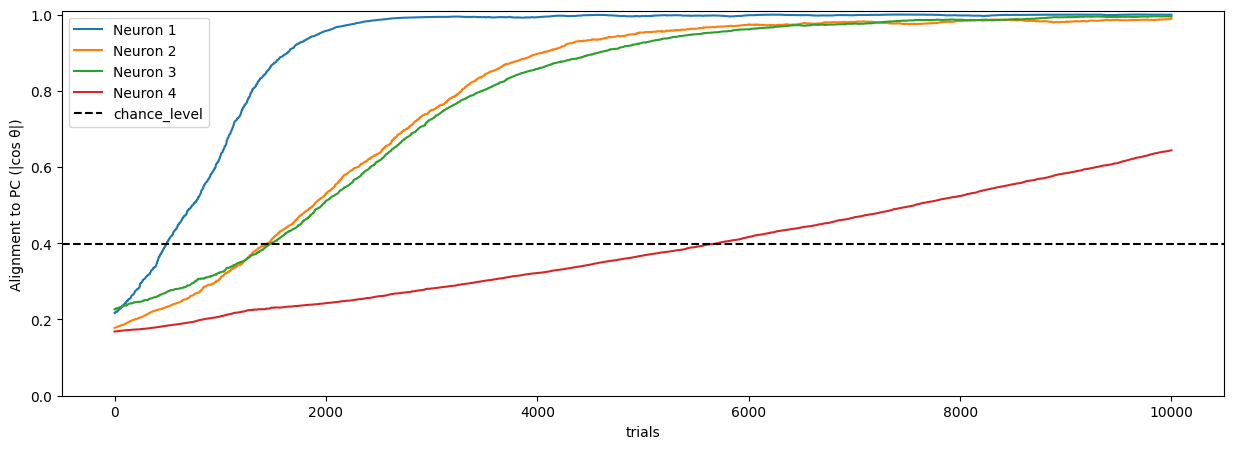

X_after
step    0 | order = [2 0 3 1] | best|corr|= [0.881 0.821 0.547 0.918]
step 1000 | order = [2 0 3 1] | best|corr|= [0.945 0.892 0.658 0.918]
step 2000 | order = [2 0 3 1] | best|corr|= [0.957 0.929 0.723 0.949]
step 3000 | order = [2 0 3 1] | best|corr|= [0.969 0.952 0.772 0.964]
step 4000 | order = [2 0 3 1] | best|corr|= [0.979 0.967 0.812 0.97 ]
step 5000 | order = [2 0 3 1] | best|corr|= [0.988 0.977 0.85  0.977]
step 6000 | order = [2 0 3 1] | best|corr|= [0.992 0.982 0.883 0.985]
step 7000 | order = [2 0 3 1] | best|corr|= [0.996 0.989 0.909 0.99 ]
step 8000 | order = [2 0 3 1] | best|corr|= [0.996 0.996 0.929 0.994]
step 9000 | order = [2 0 3 1] | best|corr|= [0.996 0.995 0.947 0.997]
step 10000 | order = [2 0 3 1] | best|corr|= [0.997 0.997 0.96  0.998]


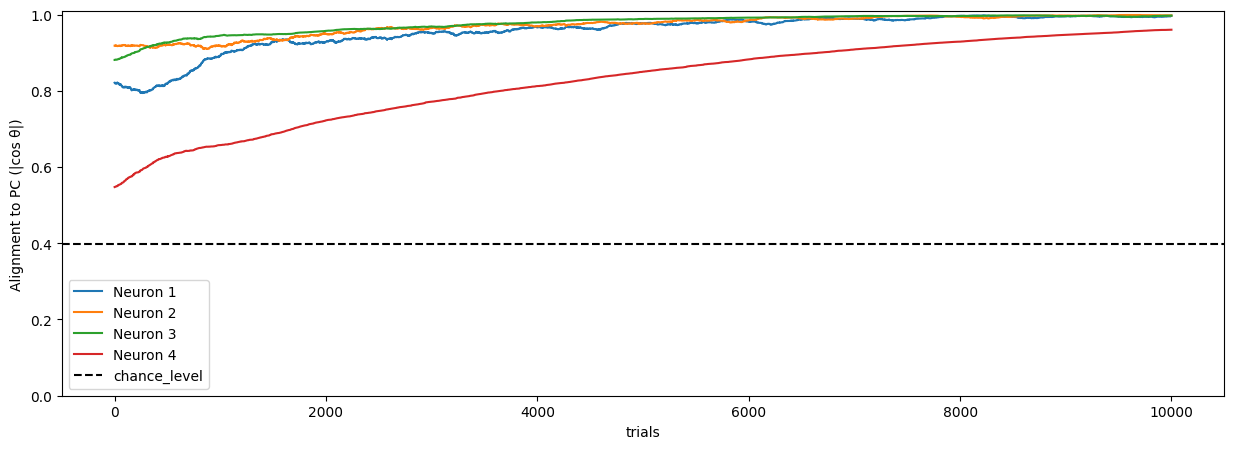

run  5
X_before
step    0 | order = [1 3 0 2] | best|corr|= [0.091 0.153 0.297 0.341]
step 1000 | order = [3 1 0 2] | best|corr|= [0.08  0.315 0.78  0.493]
step 2000 | order = [3 1 0 2] | best|corr|= [0.062 0.575 0.982 0.654]
step 3000 | order = [3 1 0 2] | best|corr|= [0.056 0.842 0.998 0.8  ]
step 4000 | order = [3 1 0 2] | best|corr|= [0.088 0.953 0.999 0.906]
step 5000 | order = [3 1 0 2] | best|corr|= [0.106 0.981 1.    0.959]
step 6000 | order = [3 1 0 2] | best|corr|= [0.122 0.992 1.    0.98 ]
step 7000 | order = [3 1 0 2] | best|corr|= [0.142 0.994 1.    0.989]
step 8000 | order = [3 1 0 2] | best|corr|= [0.165 0.994 1.    0.995]
step 9000 | order = [3 1 0 2] | best|corr|= [0.192 0.993 1.    0.998]
step 10000 | order = [3 1 0 2] | best|corr|= [0.223 0.997 0.999 0.998]


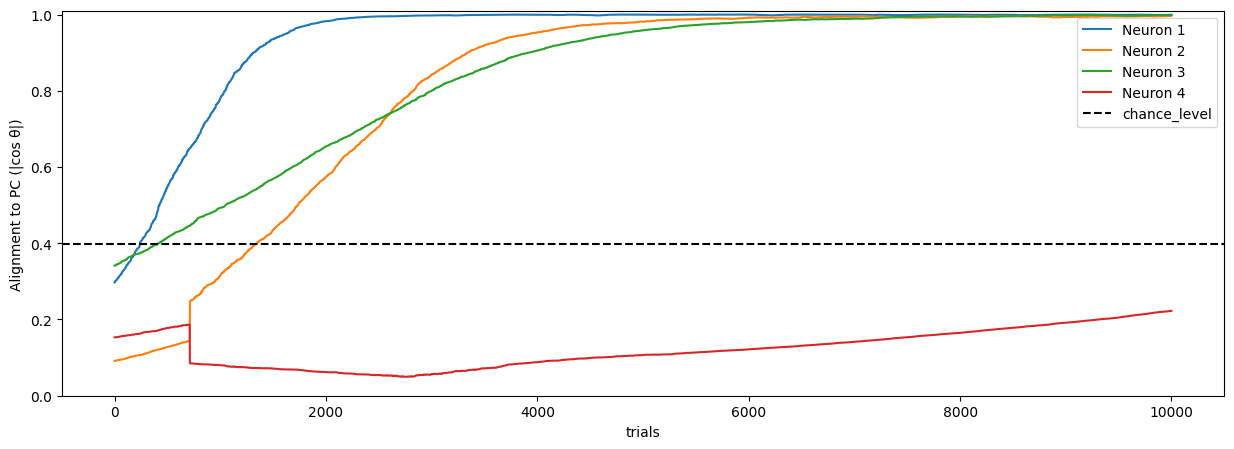

X_after
step    0 | order = [3 1 0 2] | best|corr|= [0.191 0.902 0.814 0.893]
step 1000 | order = [3 1 0 2] | best|corr|= [0.236 0.897 0.892 0.967]
step 2000 | order = [3 1 0 2] | best|corr|= [0.272 0.932 0.926 0.978]
step 3000 | order = [3 1 0 2] | best|corr|= [0.309 0.952 0.95  0.982]
step 4000 | order = [3 1 0 2] | best|corr|= [0.35  0.96  0.966 0.987]
step 5000 | order = [3 1 0 2] | best|corr|= [0.396 0.97  0.976 0.994]
step 6000 | order = [3 1 0 2] | best|corr|= [0.446 0.98  0.981 0.997]
step 7000 | order = [3 1 0 2] | best|corr|= [0.5   0.986 0.988 0.998]
step 8000 | order = [3 1 0 2] | best|corr|= [0.557 0.991 0.996 0.996]
step 9000 | order = [3 1 0 2] | best|corr|= [0.617 0.996 0.995 0.996]
step 10000 | order = [3 1 0 2] | best|corr|= [0.676 0.996 0.996 0.997]


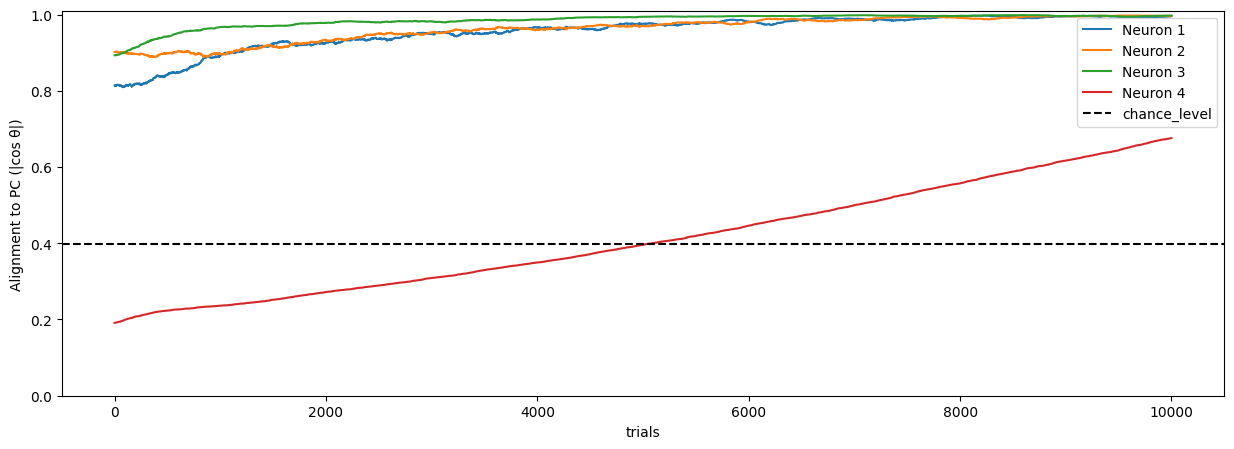

run  6
X_before
step    0 | order = [1 3 2 0] | best|corr|= [0.175 0.131 0.241 0.145]
step 1000 | order = [1 3 2 0] | best|corr|= [0.384 0.121 0.36  0.348]
step 2000 | order = [0 3 2 1] | best|corr|= [0.634 0.148 0.539 0.637]
step 3000 | order = [0 3 2 1] | best|corr|= [0.74  0.182 0.728 0.768]
step 4000 | order = [0 3 2 1] | best|corr|= [0.733 0.212 0.855 0.853]
step 5000 | order = [0 3 2 1] | best|corr|= [0.779 0.244 0.935 0.857]
step 6000 | order = [0 3 2 1] | best|corr|= [0.797 0.281 0.973 0.901]
step 7000 | order = [0 3 2 1] | best|corr|= [0.836 0.32  0.989 0.923]
step 8000 | order = [0 3 2 1] | best|corr|= [0.88  0.365 0.992 0.94 ]
step 9000 | order = [0 3 2 1] | best|corr|= [0.911 0.417 0.995 0.953]
step 10000 | order = [0 3 2 1] | best|corr|= [0.921 0.473 0.997 0.973]


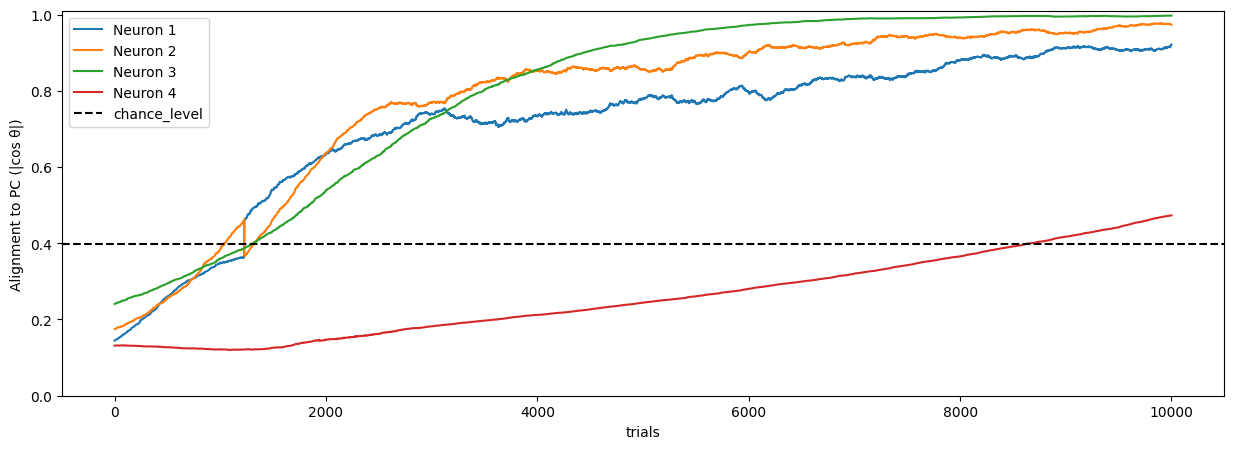

X_after
step    0 | order = [0 3 2 1] | best|corr|= [0.629 0.403 0.847 0.745]
step 1000 | order = [0 3 2 1] | best|corr|= [0.704 0.497 0.936 0.719]
step 2000 | order = [0 3 2 1] | best|corr|= [0.765 0.556 0.953 0.805]
step 3000 | order = [0 3 2 1] | best|corr|= [0.816 0.611 0.967 0.827]
step 4000 | order = [0 3 2 1] | best|corr|= [0.821 0.663 0.977 0.88 ]
step 5000 | order = [0 3 2 1] | best|corr|= [0.862 0.716 0.989 0.897]
step 6000 | order = [0 3 2 1] | best|corr|= [0.885 0.765 0.993 0.934]
step 7000 | order = [0 3 2 1] | best|corr|= [0.918 0.809 0.995 0.954]
step 8000 | order = [0 3 2 1] | best|corr|= [0.952 0.847 0.995 0.969]
step 9000 | order = [0 3 2 1] | best|corr|= [0.964 0.881 0.995 0.979]
step 10000 | order = [0 3 2 1] | best|corr|= [0.972 0.909 0.996 0.989]


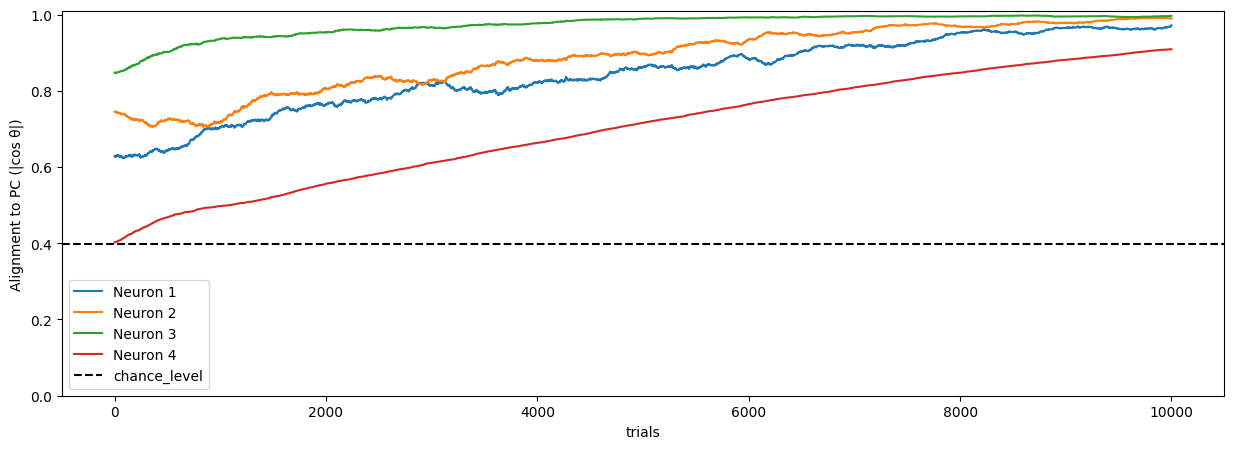

run  7
X_before
step    0 | order = [2 0 3 1] | best|corr|= [0.054 0.218 0.274 0.146]
step 1000 | order = [2 0 3 1] | best|corr|= [0.072 0.507 0.294 0.344]
step 2000 | order = [3 0 2 1] | best|corr|= [0.091 0.929 0.494 0.553]
step 3000 | order = [3 0 2 1] | best|corr|= [0.098 0.99  0.731 0.668]
step 4000 | order = [3 0 2 1] | best|corr|= [0.116 0.999 0.85  0.775]
step 5000 | order = [3 0 2 1] | best|corr|= [0.136 0.998 0.909 0.828]
step 6000 | order = [3 0 2 1] | best|corr|= [0.157 0.999 0.93  0.861]
step 7000 | order = [3 0 2 1] | best|corr|= [0.182 0.999 0.941 0.88 ]
step 8000 | order = [3 0 2 1] | best|corr|= [0.211 1.    0.953 0.902]
step 9000 | order = [3 0 2 1] | best|corr|= [0.244 1.    0.962 0.922]
step 10000 | order = [3 0 2 1] | best|corr|= [0.283 1.    0.971 0.931]


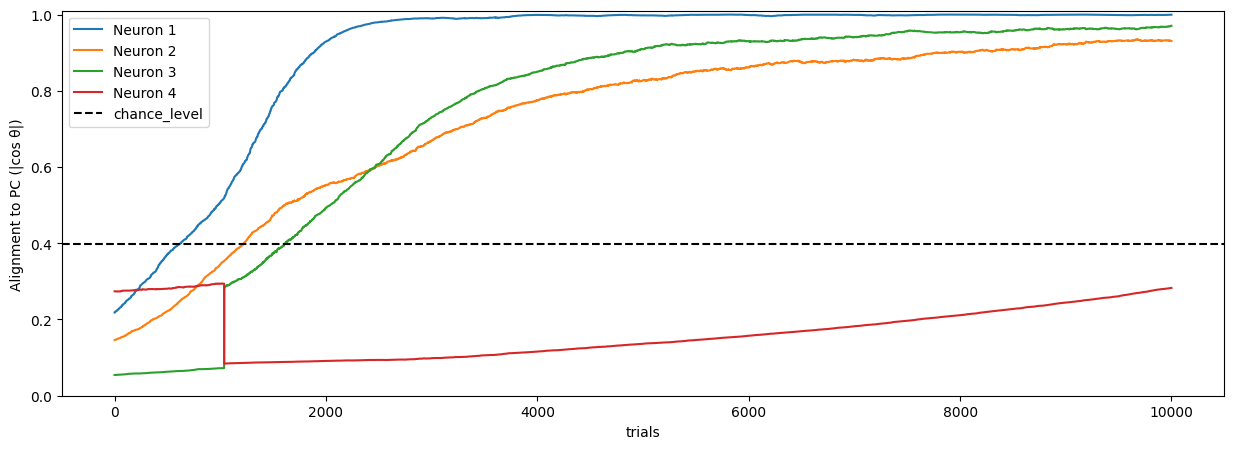

X_after
step    0 | order = [3 0 2 1] | best|corr|= [0.243 0.814 0.782 0.732]
step 1000 | order = [3 0 2 1] | best|corr|= [0.3   0.898 0.854 0.69 ]
step 2000 | order = [3 0 2 1] | best|corr|= [0.343 0.938 0.864 0.722]
step 3000 | order = [3 0 2 1] | best|corr|= [0.386 0.962 0.887 0.749]
step 4000 | order = [3 0 2 1] | best|corr|= [0.433 0.979 0.905 0.78 ]
step 5000 | order = [3 0 2 1] | best|corr|= [0.486 0.986 0.929 0.808]
step 6000 | order = [3 0 2 1] | best|corr|= [0.54  0.99  0.933 0.841]
step 7000 | order = [3 0 2 1] | best|corr|= [0.597 0.994 0.937 0.863]
step 8000 | order = [3 0 2 1] | best|corr|= [0.654 0.999 0.947 0.888]
step 9000 | order = [3 0 2 1] | best|corr|= [0.711 0.998 0.956 0.907]
step 10000 | order = [3 0 2 1] | best|corr|= [0.763 0.999 0.966 0.92 ]


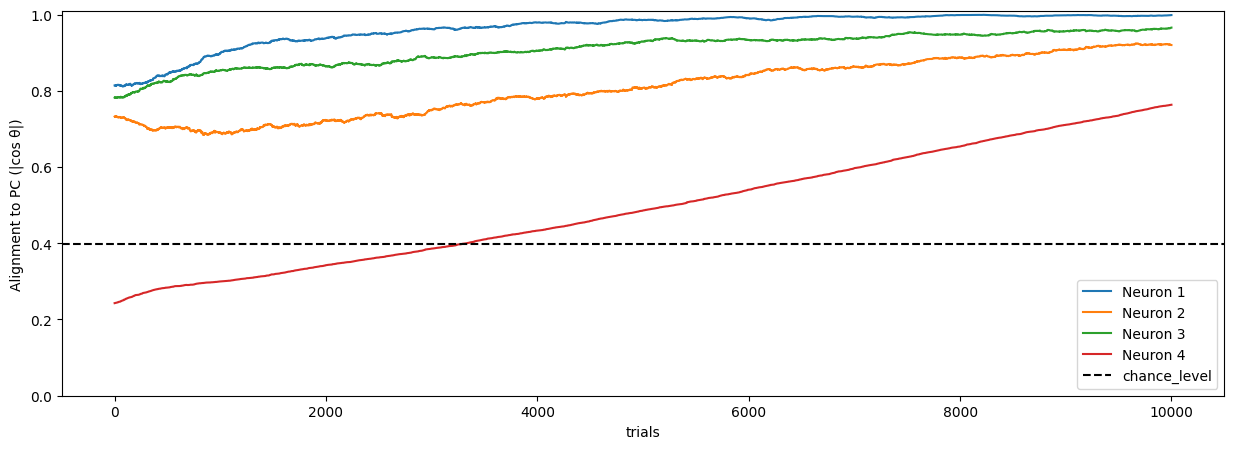

run  8
X_before
step    0 | order = [0 3 2 1] | best|corr|= [0.185 0.035 0.303 0.11 ]
step 1000 | order = [0 3 2 1] | best|corr|= [0.415 0.047 0.435 0.17 ]
step 2000 | order = [0 3 2 1] | best|corr|= [0.825 0.066 0.604 0.384]
step 3000 | order = [0 3 2 1] | best|corr|= [0.982 0.084 0.742 0.587]
step 4000 | order = [0 3 2 1] | best|corr|= [0.988 0.094 0.839 0.719]
step 5000 | order = [0 3 2 1] | best|corr|= [0.996 0.106 0.895 0.761]
step 6000 | order = [0 3 2 1] | best|corr|= [0.998 0.122 0.908 0.805]
step 7000 | order = [0 3 2 1] | best|corr|= [0.999 0.141 0.913 0.828]
step 8000 | order = [0 3 2 1] | best|corr|= [0.998 0.163 0.927 0.849]
step 9000 | order = [0 3 2 1] | best|corr|= [0.999 0.19  0.939 0.872]
step 10000 | order = [0 3 2 1] | best|corr|= [0.999 0.22  0.951 0.886]


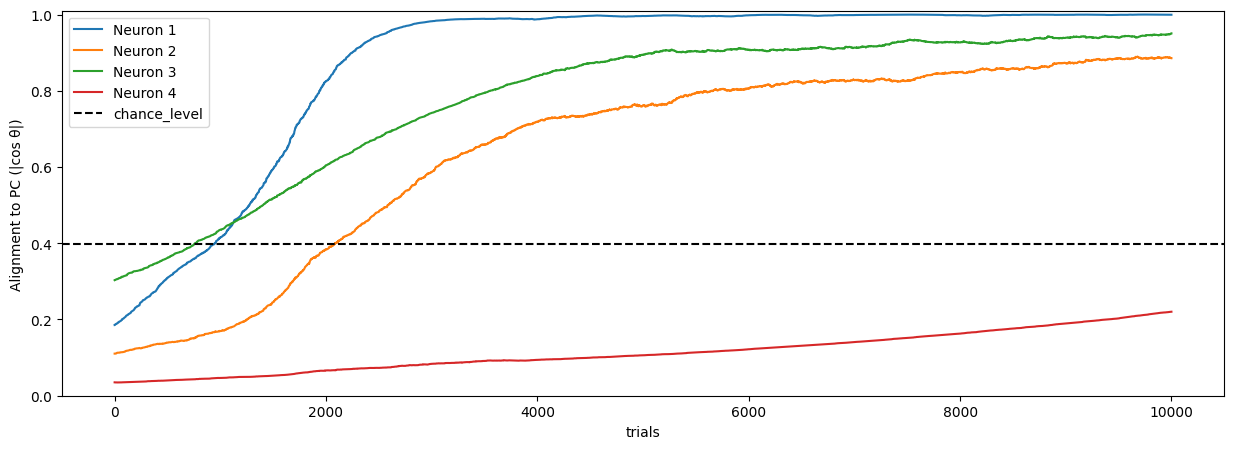

X_after
step    0 | order = [0 3 2 1] | best|corr|= [0.825 0.189 0.732 0.677]
step 1000 | order = [0 3 2 1] | best|corr|= [0.906 0.234 0.796 0.625]
step 2000 | order = [0 3 2 1] | best|corr|= [0.943 0.268 0.799 0.64 ]
step 3000 | order = [0 3 2 1] | best|corr|= [0.966 0.304 0.823 0.644]
step 4000 | order = [0 3 2 1] | best|corr|= [0.981 0.345 0.834 0.663]
step 5000 | order = [0 3 2 1] | best|corr|= [0.989 0.391 0.852 0.672]
step 6000 | order = [0 3 2 1] | best|corr|= [0.993 0.44  0.842 0.697]
step 7000 | order = [0 3 2 1] | best|corr|= [0.996 0.494 0.837 0.714]
step 8000 | order = [0 3 2 1] | best|corr|= [0.999 0.551 0.85  0.725]
step 9000 | order = [0 3 2 1] | best|corr|= [0.998 0.611 0.868 0.736]
step 10000 | order = [0 3 2 1] | best|corr|= [0.999 0.67  0.88  0.756]


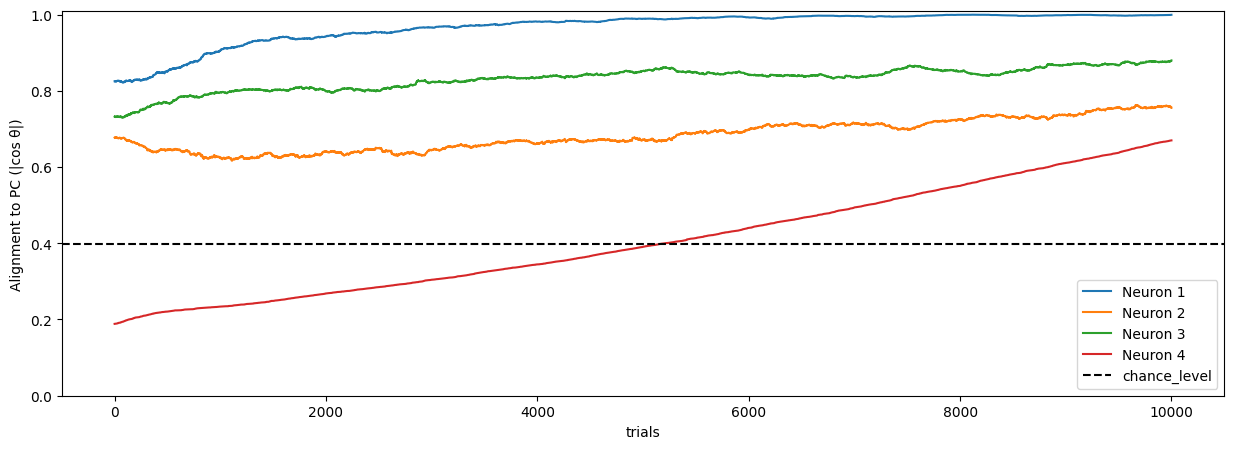

run  9
X_before
step    0 | order = [3 1 2 0] | best|corr|= [0.215 0.222 0.128 0.039]
step 1000 | order = [3 1 0 2] | best|corr|= [0.223 0.365 0.349 0.048]
step 2000 | order = [3 1 0 2] | best|corr|= [0.221 0.368 0.639 0.043]
step 3000 | order = [1 2 0 3] | best|corr|= [0.749 0.252 0.897 0.049]
step 4000 | order = [1 2 0 3] | best|corr|= [0.932 0.41  0.909 0.05 ]
step 5000 | order = [1 2 0 3] | best|corr|= [0.967 0.567 0.951 0.056]
step 6000 | order = [1 2 0 3] | best|corr|= [0.985 0.733 0.962 0.065]
step 7000 | order = [1 2 0 3] | best|corr|= [0.991 0.862 0.976 0.077]
step 8000 | order = [1 2 0 3] | best|corr|= [0.994 0.938 0.981 0.096]
step 9000 | order = [1 2 0 3] | best|corr|= [0.995 0.975 0.993 0.112]
step 10000 | order = [1 2 0 3] | best|corr|= [0.993 0.991 0.994 0.129]


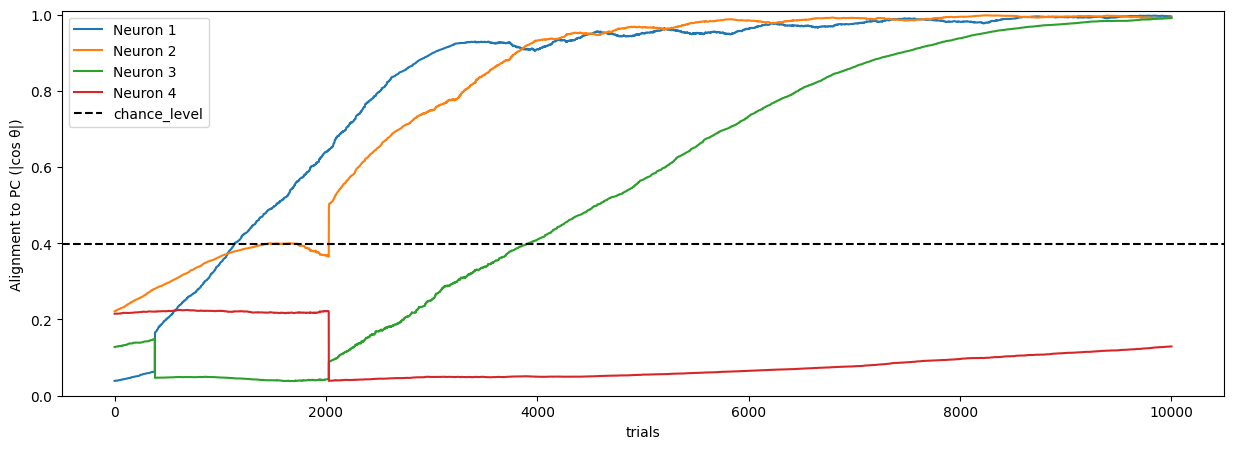

X_after
step    0 | order = [1 2 0 3] | best|corr|= [0.896 0.851 0.847 0.112]
step 1000 | order = [1 2 0 3] | best|corr|= [0.88  0.947 0.926 0.134]
step 2000 | order = [1 2 0 3] | best|corr|= [0.912 0.964 0.953 0.155]
step 3000 | order = [1 2 0 3] | best|corr|= [0.94  0.972 0.97  0.177]
step 4000 | order = [1 2 0 3] | best|corr|= [0.948 0.979 0.983 0.202]
step 5000 | order = [1 2 0 3] | best|corr|= [0.962 0.989 0.987 0.232]
step 6000 | order = [1 2 0 3] | best|corr|= [0.972 0.993 0.99  0.266]
step 7000 | order = [1 2 0 3] | best|corr|= [0.979 0.995 0.994 0.305]
step 8000 | order = [1 2 0 3] | best|corr|= [0.987 0.993 0.998 0.348]
step 9000 | order = [1 2 0 3] | best|corr|= [0.992 0.994 0.997 0.398]
step 10000 | order = [1 2 0 3] | best|corr|= [0.991 0.996 0.998 0.453]


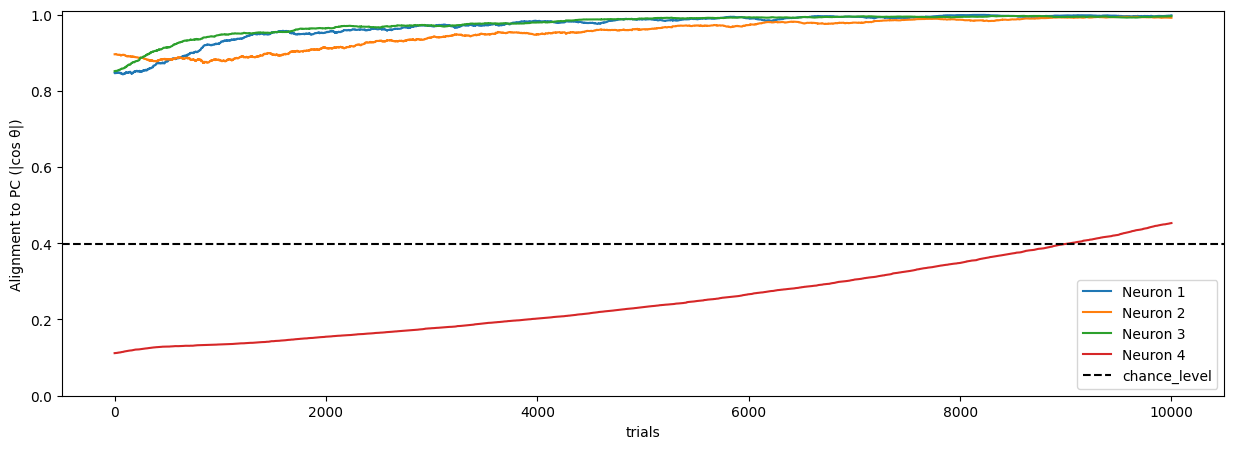

run 10
X_before
step    0 | order = [1 0 3 2] | best|corr|= [0.224 0.045 0.082 0.232]
step 1000 | order = [1 3 0 2] | best|corr|= [0.339 0.002 0.209 0.356]
step 2000 | order = [0 3 1 2] | best|corr|= [0.424 0.002 0.271 0.456]
step 3000 | order = [0 3 2 1] | best|corr|= [0.795 0.003 0.444 0.48 ]
step 4000 | order = [0 3 2 1] | best|corr|= [0.85  0.01  0.689 0.638]
step 5000 | order = [0 3 2 1] | best|corr|= [0.921 0.014 0.826 0.711]
step 6000 | order = [0 3 2 1] | best|corr|= [0.944 0.011 0.882 0.781]
step 7000 | order = [0 3 2 1] | best|corr|= [0.969 0.011 0.903 0.811]
step 8000 | order = [0 3 2 1] | best|corr|= [0.979 0.013 0.921 0.835]
step 9000 | order = [0 3 2 1] | best|corr|= [0.991 0.015 0.935 0.864]
step 10000 | order = [0 3 2 1] | best|corr|= [0.993 0.018 0.948 0.875]


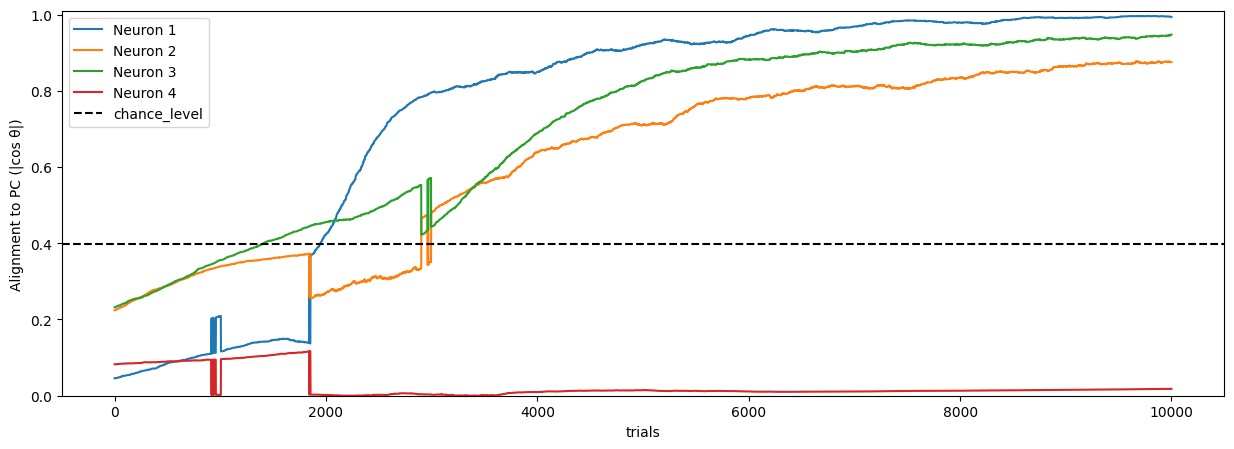

X_after
step    0 | order = [0 3 2 1] | best|corr|= [0.847 0.015 0.725 0.685]
step 1000 | order = [0 3 2 1] | best|corr|= [0.925 0.019 0.793 0.636]
step 2000 | order = [0 3 2 1] | best|corr|= [0.956 0.022 0.797 0.645]
step 3000 | order = [0 3 2 1] | best|corr|= [0.975 0.026 0.821 0.648]
step 4000 | order = [0 3 2 1] | best|corr|= [0.987 0.029 0.833 0.664]
step 5000 | order = [0 3 2 1] | best|corr|= [0.992 0.034 0.851 0.671]
step 6000 | order = [0 3 2 1] | best|corr|= [0.995 0.039 0.84  0.695]
step 7000 | order = [0 3 2 1] | best|corr|= [0.997 0.045 0.834 0.711]
step 8000 | order = [0 3 2 1] | best|corr|= [0.999 0.053 0.848 0.721]
step 9000 | order = [0 3 2 1] | best|corr|= [0.999 0.062 0.865 0.732]
step 10000 | order = [0 3 2 1] | best|corr|= [0.999 0.072 0.876 0.751]


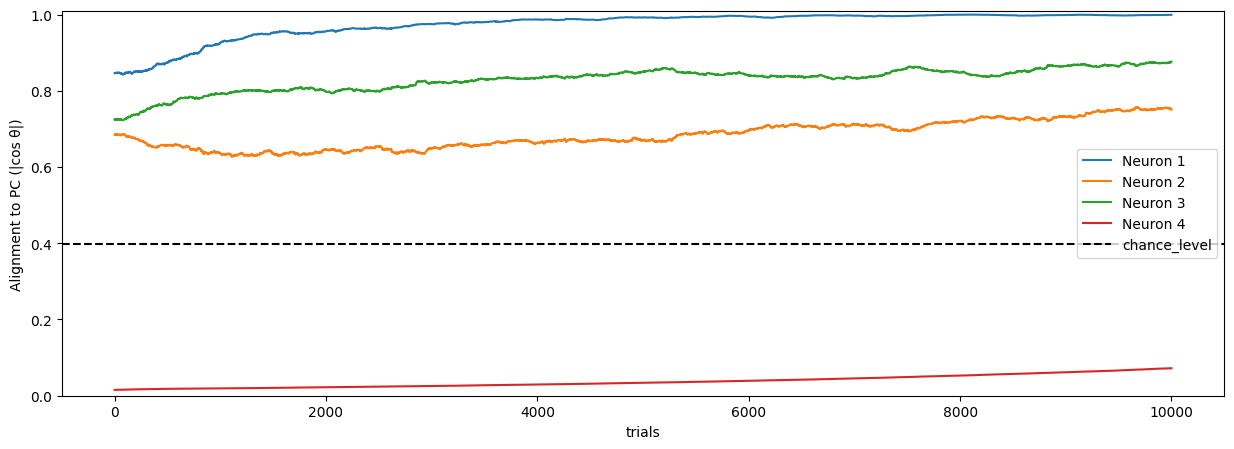

<Figure size 640x480 with 0 Axes>

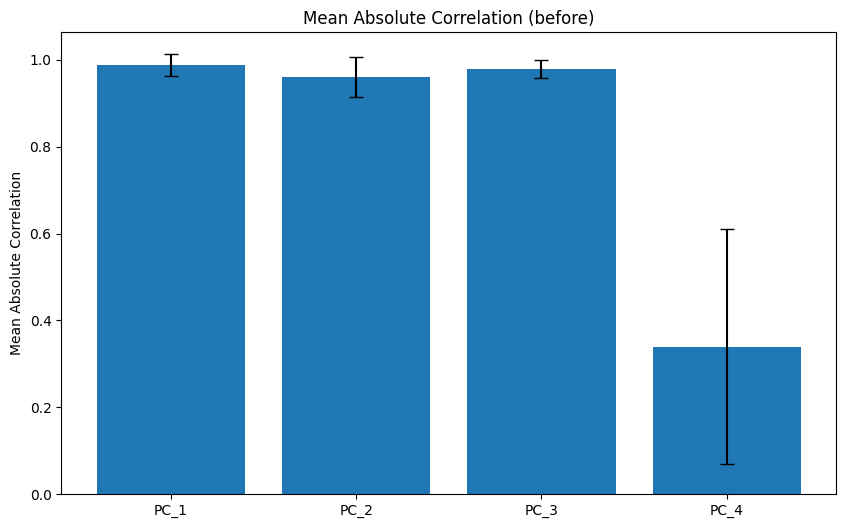

<Figure size 640x480 with 0 Axes>

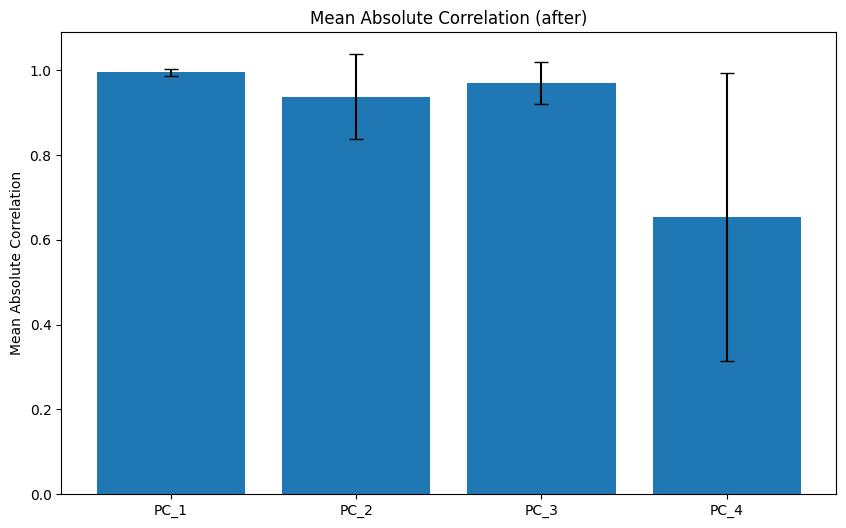

In [21]:
# leen_model  = OneShotLeenCompletePCA(**model_paras)

leen_model = OneShotLeenReislebenPCA(**model_paras)

two_phase_training_testing(leen_model, X_before, X_after, m, 
                            # model_paras_after = model_paras_after, 
                            runs = 10, graph = True)

### decoding task variable

In [24]:
from hebbian.utils import pca_topk, best_match_align_eigenvectors
from hebbian.models import SangerNetwork, OneShotLeenReislebenPCA, OneShotLeenCompletePCA
### calculate the task variable across time

# generate values between 0 and 1 for m number
rng_para = np.random.default_rng(seed=42)
params = rng_para.random(m)
batch_size = 1
# model = SangerNetwork(output_size=m, learning_rate=0.01)
model = OneShotLeenCompletePCA(**model_paras)
# model = OneShotLeenReislebenPCA(**model_paras)


# get the weighted sum of the PC scores across all samples, using X_before
pcs, _, scores = pca_topk(X_before, k=m)
# calculate the task variable across time
task_var = np.dot(scores, params)


for step in range(0, n_samples, batch_size):
    X_train = X_before[step:step+batch_size]
    model.step(X_train)
    # use the X_mask to incrementally reveal the input matrix, and update the model

Y_output = model.transform(X_before)
# get the best match alignment between Y_output and PC_scores by hungarian algorithm
try:
    V = model.V
except:
    V = None

order, sim, _ = best_match_align_eigenvectors(model.W, V=V, eigenvectors=pcs)
print(order, sim)


# Check and correct signs by comparing with PC scores
# For each aligned component, check if it correlates positively or negatively with the corresponding PC
signs = np.ones(m)
for i in range(m):
    pc_idx = order[i]  # Which PC this Y_output column is matched to
    # Compute correlation between Y_output[:, i] and scores[:, pc_idx]
    corr = np.corrcoef(Y_output[:, i], scores[:, pc_idx])[0, 1]
    # If negative correlation, flip the sign
    if corr < 0:
        signs[i] = -1

# Apply sign corrections
Y_output_signed = Y_output * signs[None, :]

# Now compute task variable with sign-corrected output
task_var_tilde = np.dot(Y_output_signed, params)

[1 2 3 0] [0.92520138 0.96755694 0.73476004 0.7494231 ]


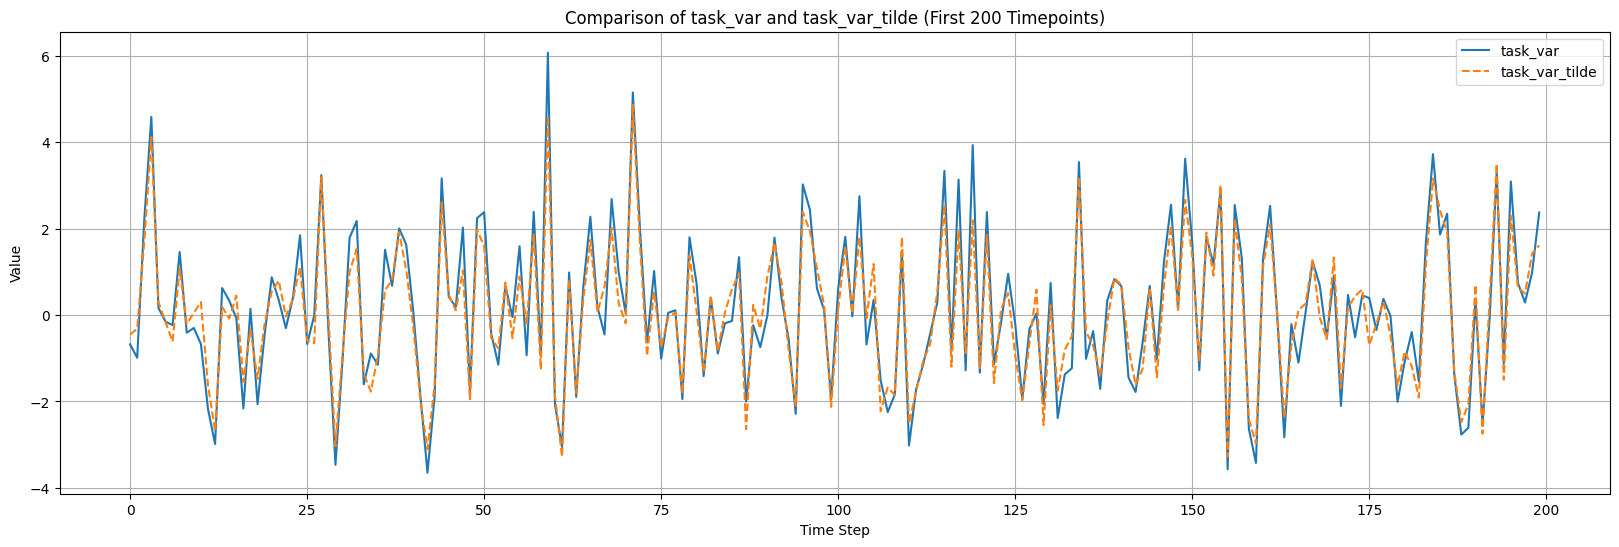

correlation between task_var and task_var_tilde: 0.962689563692544


In [25]:
# visualize
plt.figure(figsize=(20, 6))
plt.plot(task_var[:200], label='task_var')
plt.plot(task_var_tilde[:200], label='task_var_tilde', linestyle='--')
plt.xlabel('Time Step') # Assuming an underlying time or step index
plt.ylabel('Value')
plt.title('Comparison of task_var and task_var_tilde (First 200 Timepoints)')
plt.legend()
plt.grid(True)
plt.show()

# get correlation between task_var and task_var_tilde
corr = np.corrcoef(task_var, task_var_tilde)[0, 1]
print(f"correlation between task_var and task_var_tilde: {corr}")


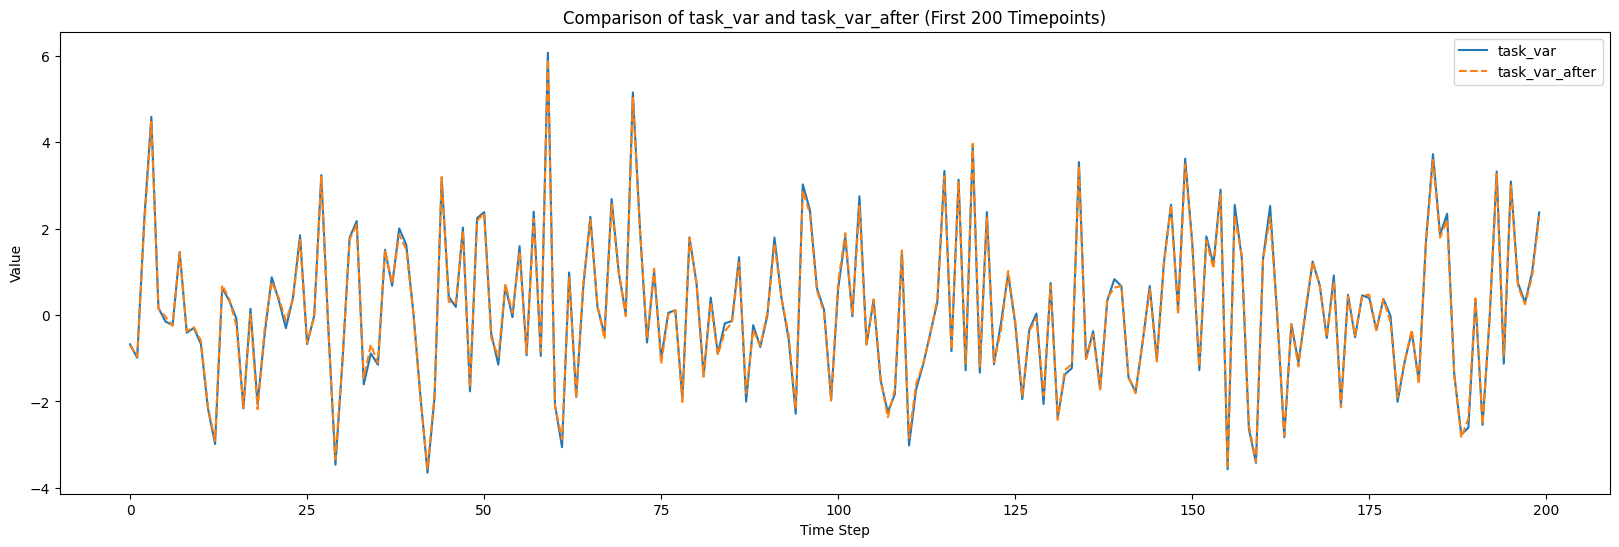

In [29]:
from hebbian.utils import rotation_matrix_nd
# rotat the pcs by phi_deg
R = rotation_matrix_nd( N, axis1=0, axis2=1, phi_rad=np.deg2rad(phi_deg))

X_after = X_before @ R
# project the data after rotation
pcs_after = R @ pcs

task_var_after = np.dot(X_after @ pcs_after, params)

# plot task_var and task_var_after
plt.figure(figsize=(20, 6))
plt.plot(task_var[:200], label='task_var')
plt.plot(task_var_after[:200], label='task_var_after', linestyle='--')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.title('Comparison of task_var and task_var_after (First 200 Timepoints)')
plt.legend()
plt.show()

### Chance level exploration with random vectors

In [ ]:
from hebbian.utils import pca_topk
from scipy.stats import pearsonr
from hebbian.utils import best_match_align_timeseries



def random_projection_chance_corr1(X, n_samples=1000, seed=None):
    """
    Calculate the expected absolute correlation between a random projection 
    of X and the PC projections of X.
    
    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Input data
    n_samples : int, default=1000
        Number of random vectors to sample for Monte Carlo estimation
    seed : int or None
        Random seed
        
    Returns
    -------
    expected_corr : float
        Expected absolute correlation between random projection and PC projections
    std_corr : float
        Standard deviation of correlations (for reference)
    """
    X = np.asarray(X, dtype=float)
    n, d = X.shape
    
    # Center the data
    Xc = X - X.mean(axis=0, keepdims=True)
    
    # Get PCs
    _, _, PC_scores = pca_topk(X, d, center=True)
    print(f"shape of PC_scores: {PC_scores.shape}")
    
    # Sample random unit vectors
    rng = np.random.default_rng(seed)
    correlations = []
    
    for _ in range(n_samples):
        # Random unit vector in d-dimensional space
        w = rng.normal(size=d)
        w = w / (np.linalg.norm(w) + 1e-12)
        
        # Project X onto random direction
        y_random = Xc @ w
        
        # Compute correlation with each PC
        pc_corrs = []
        # print(f"shape of y_random: {y_random.shape}")
        
        # for j in range(min(d, PC_scores.shape[1])):
        # for j in range(2):
        # calculate the covariance between y_random and PC_scores[:, 0]
        cov = np.cov(y_random, PC_scores[:, 0])/np.cov(PC_scores[:, 0], PC_scores[:, 0])
        # pc_corrs.append(abs(r))
        pc_corrs.append(abs(cov[0, 1]))

        
        # Take max correlation (best match, like Hungarian algorithm does)
        correlations.append(max(pc_corrs))
    
    return np.mean(correlations), np.std(correlations)


def random_projection_chance_corr(X, m=2, n_samples=1000, metric="corr", absolute=True, seed=None):
    """
    Calculate the expected absolute correlation between random projections 
    of X and the PC projections of X, using the same matching procedure
    as the actual analysis (best_match_align_timeseries).
    
    This generates m random unit vectors, projects X onto them, and uses
    Hungarian matching to find optimal alignment with PCs, just like the
    real analysis does.
    
    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Input data
    m : int, default=2
        Number of random projections (should match output_dim of your model)
    n_samples : int, default=1000
        Number of random vector sets to sample for Monte Carlo estimation
    metric : {"corr", "cosine"}, default="corr"
        Metric to use (should match what you use in best_match_align_timeseries)
    absolute : bool, default=True
        Whether to use absolute correlations (should match your usage)
    seed : int or None
        Random seed
        
    Returns
    -------
    expected_corr : float
        Expected absolute correlation after optimal matching
    std_corr : float
        Standard deviation of correlations (for reference)
    all_corrs : ndarray, shape (n_samples, m)
        All correlation values from each trial (for distribution analysis)
    """
    X = np.asarray(X, dtype=float)
    n, d = X.shape
    
    # Center the data
    Xc = X - X.mean(axis=0, keepdims=True)
    
    # Get PC scores (top m PCs)
    _, _, PC_scores = pca_topk(X, d, center=True)
    PC_scores_m = PC_scores[:, :m]  # Use only top m PCs
    
    # Sample random projections
    rng = np.random.default_rng(seed)
    all_similarities = []
    
    for trial in range(n_samples):
        # Generate m random unit vectors in d-dimensional space
        W_random = rng.normal(size=(m, d))
        # Normalize each row to unit length
        W_random = W_random / (np.linalg.norm(W_random, axis=1, keepdims=True) + 1e-12)
        
        # Project X onto random directions: Y_random = Xc @ W_random.T
        # Shape: (n, d) @ (d, m) = (n, m)
        Y_random = Xc @ W_random.T
        
        # Use the same matching procedure as actual analysis
        perm, similarity, _, _ = best_match_align_timeseries(
            Y_random, PC_scores_m, 
            metric=metric, 
            absolute=absolute
        )
        
        # similarity is already the matched correlations
        all_similarities.append(similarity)
    
    all_similarities = np.array(all_similarities)  # Shape: (n_samples, m)
    
    # Compute statistics
    expected_corr = np.mean(all_similarities)
    std_corr = np.std(all_similarities)
    
    return expected_corr, std_corr, all_similarities


def random_projection_chance_corr_per_pc(X, m=2, n_samples=1000, metric="corr", absolute=True, seed=None):
    """
    Same as random_projection_chance_corr but returns per-PC statistics.
    
    Returns
    -------
    expected_corr_per_pc : ndarray, shape (m,)
        Expected correlation for each PC (after sorting by PC order)
    std_corr_per_pc : ndarray, shape (m,)
        Standard deviation for each PC
    """
    expected_corr, std_corr, all_similarities = random_projection_chance_corr(
        X, m, n_samples, metric, absolute, seed
    )
    
    # Sort similarities by PC order (they're already matched, but we want PC1, PC2, ...)
    # The similarities are already optimally matched, so we sort them
    all_similarities_sorted = np.sort(all_similarities, axis=1)  # Sort each row
    
    expected_corr_per_pc = np.mean(all_similarities_sorted, axis=0)
    std_corr_per_pc = np.std(all_similarities_sorted, axis=0)
    
    return expected_corr_per_pc, std_corr_per_pc, all_similarities_sorted



def analytical_chance_corr(input_dim):
    """
    Analytical approximation for expected correlation between random projection
    and PC projection, assuming isotropic data (all eigenvalues equal).
    
    This is a simplified case. For non-isotropic data, use random_projection_chance_corr.
    
    Parameters
    ----------
    input_dim : int
        Input dimensionality
        
    Returns
    -------
    float 
        Expected absolute correlation (approximate)
    """
    # For isotropic case, this reduces to the random vector chance level
    # For non-isotropic, it's more complex and depends on eigenvalue distribution
    return np.sqrt(2 / (np.pi * input_dim))

In [ ]:
print(f"Analytical chance correlation: {analytical_chance_corr(N):.3f}")

In [ ]:
from hebbian.utils import generate_covariance_matrix
for i in range(2, 10, 1):
    N = i
    m = 2
    phi_deg = 45.0
    n_samples = 10001
    # get /sigma
    Sigma = np.array([[1.0, 0.2], [0.2, 1.0]])
    Sigma_rot = rotate_cov_nd(Sigma, np.deg2rad(phi_deg), axis1=0, axis2=1)

    X_before, X_after = instantiate_before_after_X(Sigma, Sigma_rot, N = N, seed=X_seed, n_samples=n_samples)
    print(f" input dimension = {N}")
    print(f"shape of X_before: {X_before.shape}")
    # In Y_aligned_training_testing_online or similar:
    expected_corr, std_corr = random_projection_chance_corr1(X_before, n_samples=1000)
    print(f"Expected chance correlation: {expected_corr:.3f} ± {std_corr:.3f}")

In [ ]:
# In your notebook or analysis:

# Or get per-PC statistics
expected_per_pc, std_per_pc, _ = random_projection_chance_corr_per_pc(
    X_before, m=2, n_samples=1000
)
print(f"Expected chance correlation per PC: PC1={expected_per_pc[0]:.3f}, PC2={expected_per_pc[1]:.3f}")